In [1]:
import pandas as pd


In [2]:
df = pd.read_excel("/Users/rupamhaldar/Desktop/CChunP/data/telco_cleaned.xlsx")

In [3]:
df.head()

,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,...,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV
0,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239
1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701
2,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,...,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372
3,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,...,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003
4,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,...,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340


In [17]:
df.isnull().sum()


Country              0
State                0
City                 0
Zip Code             0
Lat Long             0
Latitude             0
Longitude            0
Gender               0
Senior Citizen       0
Partner              0
Dependents           0
Tenure Months        0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
Churn Label          0
Churn Value          0
Churn Score          0
CLTV                 0
dtype: int64

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Country            7043 non-null   str    
 1   State              7043 non-null   str    
 2   City               7043 non-null   str    
 3   Zip Code           7043 non-null   int64  
 4   Lat Long           7043 non-null   str    
 5   Latitude           7043 non-null   float64
 6   Longitude          7043 non-null   float64
 7   Gender             7043 non-null   str    
 8   Senior Citizen     7043 non-null   str    
 9   Partner            7043 non-null   str    
 10  Dependents         7043 non-null   str    
 11  Tenure Months      7043 non-null   int64  
 12  Phone Service      7043 non-null   str    
 13  Multiple Lines     7043 non-null   str    
 14  Internet Service   7043 non-null   str    
 15  Online Security    7043 non-null   str    
 16  Online Backup      7043 non-null   

In [5]:
df.value_counts

<bound method DataFrame.value_counts of             Country       State          City  Zip Code  \
0     United States  California   Los Angeles     90003   
1     United States  California   Los Angeles     90005   
2     United States  California   Los Angeles     90006   
3     United States  California   Los Angeles     90010   
4     United States  California   Los Angeles     90015   
...             ...         ...           ...       ...   
7038  United States  California       Landers     92285   
7039  United States  California      Adelanto     92301   
7040  United States  California         Amboy     92304   
7041  United States  California  Angelus Oaks     92305   
7042  United States  California  Apple Valley     92308   

                    Lat Long   Latitude   Longitude  Gender Senior Citizen  \
0     33.964131, -118.272783  33.964131 -118.272783    Male             No   
1      34.059281, -118.30742  34.059281 -118.307420  Female             No   
2     34.048013, 

In [7]:
df['Churn Label'].value_counts()


Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [8]:
import matplotlib.pyplot as plt

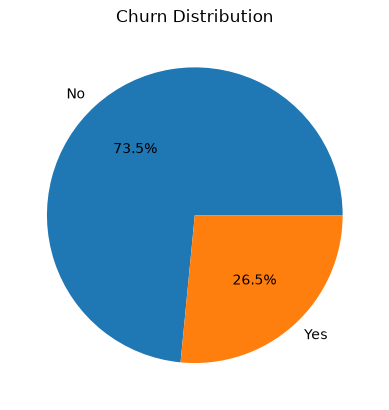

In [10]:
# Count values
counts = df['Churn Label'].value_counts()

# Labels (Yes / No)
labels = counts.index

# Plot pie chart
plt.pie(counts, labels=labels, autopct='%1.1f%%')

plt.title('Churn Distribution')
plt.show()

**customer 73.5% stay and 26.5% churn**

In [11]:
import seaborn as sns 

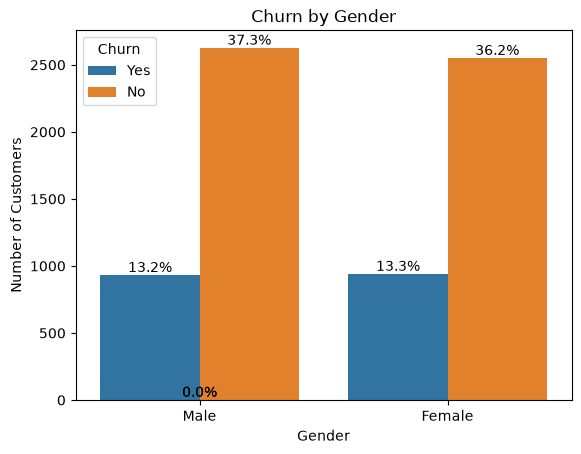

In [12]:
total = len(df)


ax = sns.countplot(x='Gender', hue='Churn Label', data=df)

# Annotate bars with percentages
for p in ax.patches:
    percentage = 100 * p.get_height() / total
    ax.annotate(f'{percentage:.1f}%', 
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')

plt.title('Churn by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')
plt.show()

Churn rates appear similar between male and female customers, suggesting gender alone may not be a strong factor in predicting churn.

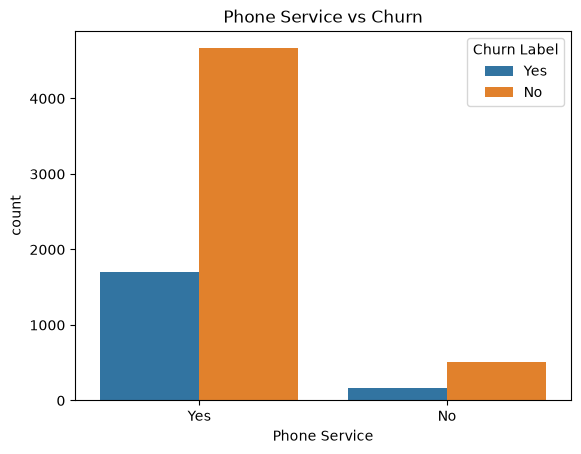

Most customers have phone service.



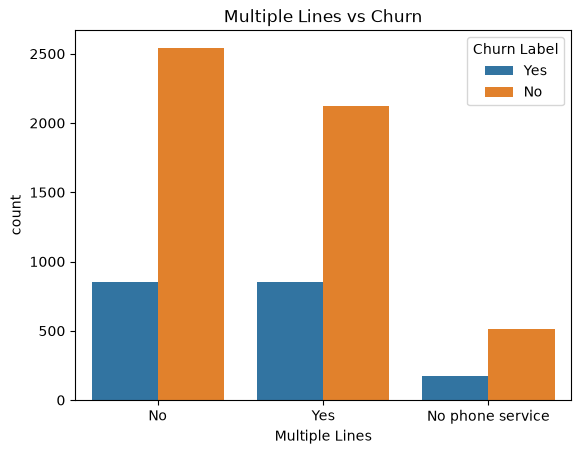

Customers without multiple lines have slightly lower churn.



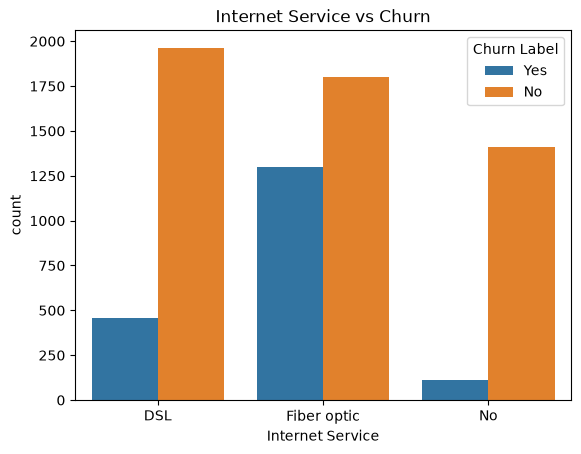

Fiber optic users tend to churn more; no internet service rarely churns.



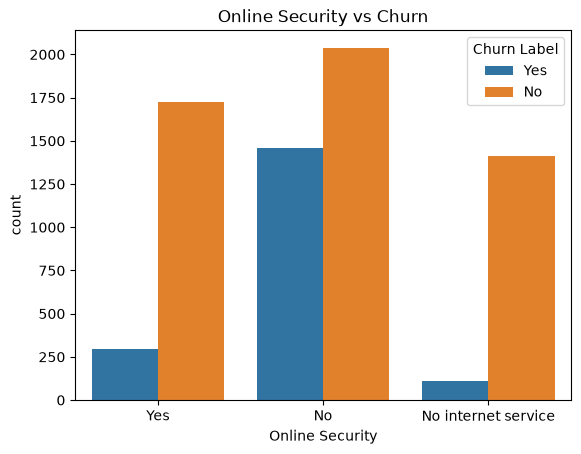

Customers without online security show higher churn.



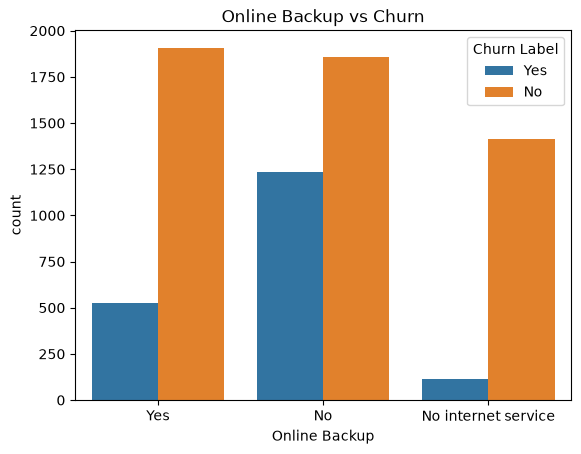

Customers without online backup churn more; backup helps retention.



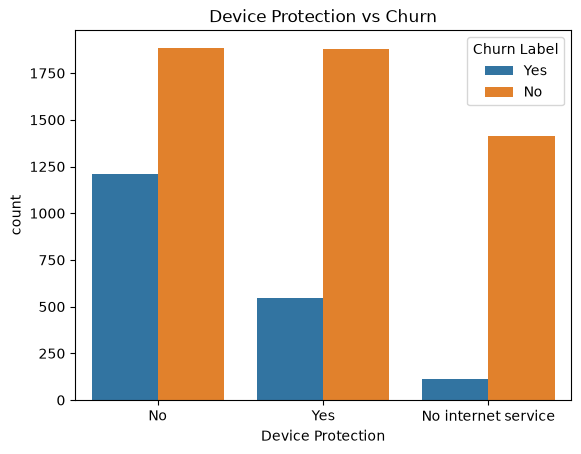

Lacking device protection correlates with higher churn.



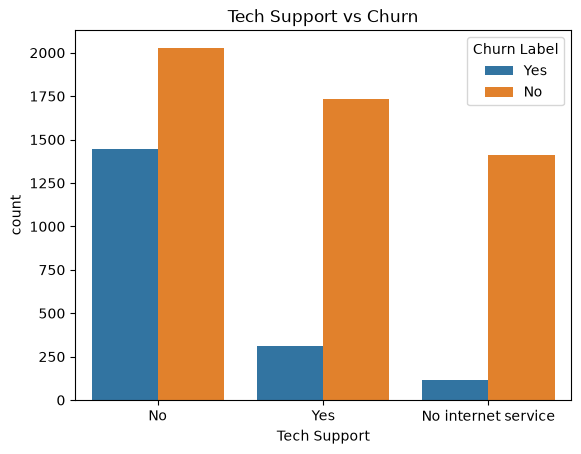

No tech support is strongly linked to higher churn.



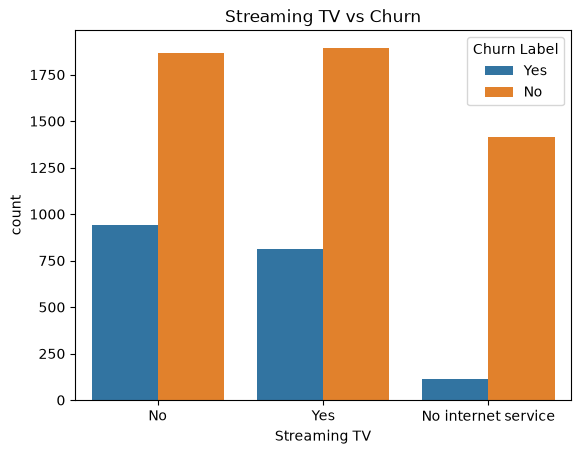

Streaming TV may slightly decrease churn.



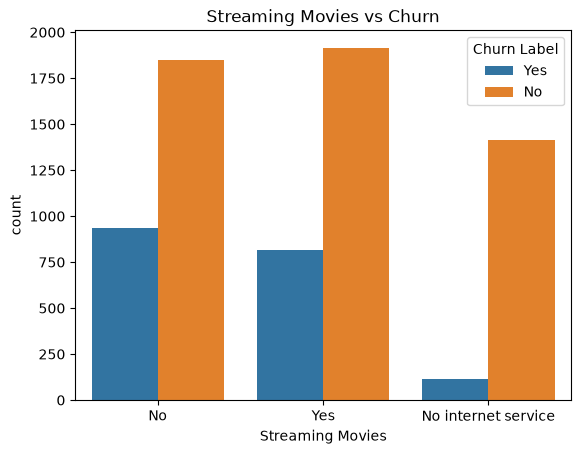

Similar to streaming TV, streaming movies have a small effect on churn.



In [16]:
service_cols = ['Phone Service', 'Multiple Lines', 'Internet Service',
                'Online Security', 'Online Backup', 'Device Protection',
                'Tech Support', 'Streaming TV', 'Streaming Movies']


# Dictionary of comments for each column
comments = {
    'Phone Service': "Most customers have phone service.",
    'Multiple Lines': "Customers without multiple lines have slightly lower churn.",
    'Internet Service': "Fiber optic users tend to churn more; no internet service rarely churns.",
    'Online Security': "Customers without online security show higher churn.",
    'Online Backup': "Customers without online backup churn more; backup helps retention.",
    'Device Protection': "Lacking device protection correlates with higher churn.",
    'Tech Support': "No tech support is strongly linked to higher churn.",
    'Streaming TV': "Streaming TV may slightly decrease churn.",
    'Streaming Movies': "Similar to streaming TV, streaming movies have a small effect on churn."
}
# Loop through columns and plot
for col in service_cols:
    ax = sns.countplot(x=col, hue='Churn Label', data=df)
    plt.title(f"{col} vs Churn")
    
    # Show the plot
    plt.show()
    
    # Print the comment under the plot
    #print(f"Comment for {col}: {comments[col]}\n")
    print(f"{comments[col]}\n")

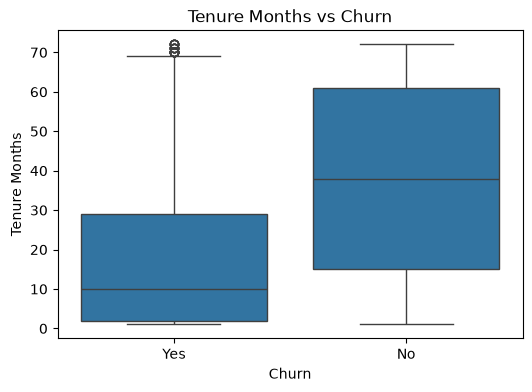

Customers with shorter tenure are more likely to churn. Longer-tenured customers tend to stay, showing that loyalty increases over time.



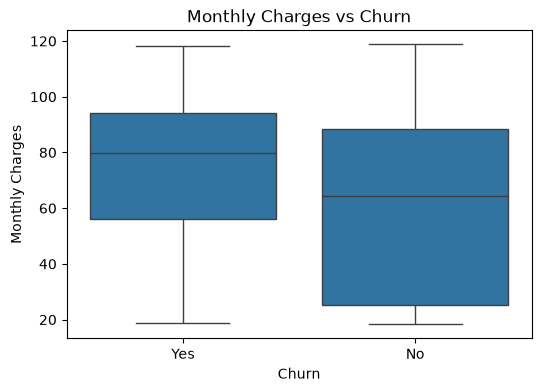

Customers with higher monthly charges show a slightly higher churn rate. Low-to-mid charges are associated with more retained customers.



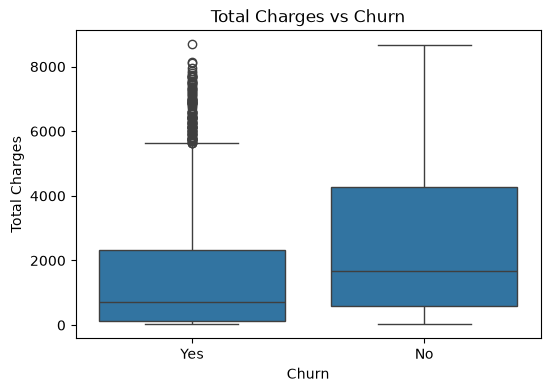

Customers with low total charges tend to churn more, usually because they are newer customers. High total charges often indicate long-term customers who are less likely to churn.



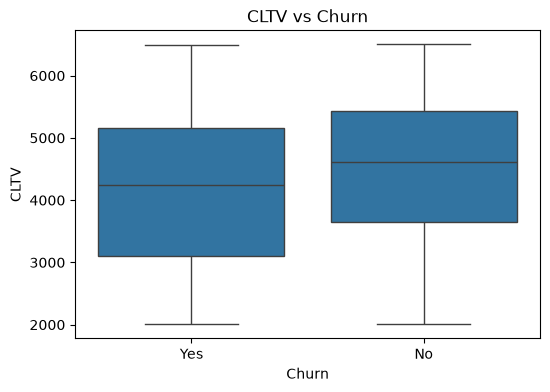

Customers with low CLTV are more likely to churn. Higher CLTV correlates with retention, suggesting these customers are more valuable and loyal.



In [21]:
 #Ensure numeric columns are truly numeric
numeric_cols = ['Tenure Months','Monthly Charges','Total Charges','CLTV']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Optional: drop rows with missing values for these columns
my_data_clean = df.dropna(subset=numeric_cols)

numeric_comments = { 'Tenure Months': "Customers with shorter tenure are more likely to churn. Longer-tenured customers tend to stay, showing that loyalty increases over time.", 
                    'Monthly Charges': "Customers with higher monthly charges show a slightly higher churn rate. Low-to-mid charges are associated with more retained customers.",
                    'Total Charges': "Customers with low total charges tend to churn more, usually because they are newer customers. High total charges often indicate long-term customers who are less likely to churn.", 
                    'CLTV': "Customers with low CLTV are more likely to churn. Higher CLTV correlates with retention, suggesting these customers are more valuable and loyal." }

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Churn Label', y=col, data=my_data_clean)
    plt.title(f"{col} vs Churn")
    plt.xlabel("Churn")
    plt.ylabel(col)
    plt.show()
    
    print(f"{numeric_comments[col]}\n")

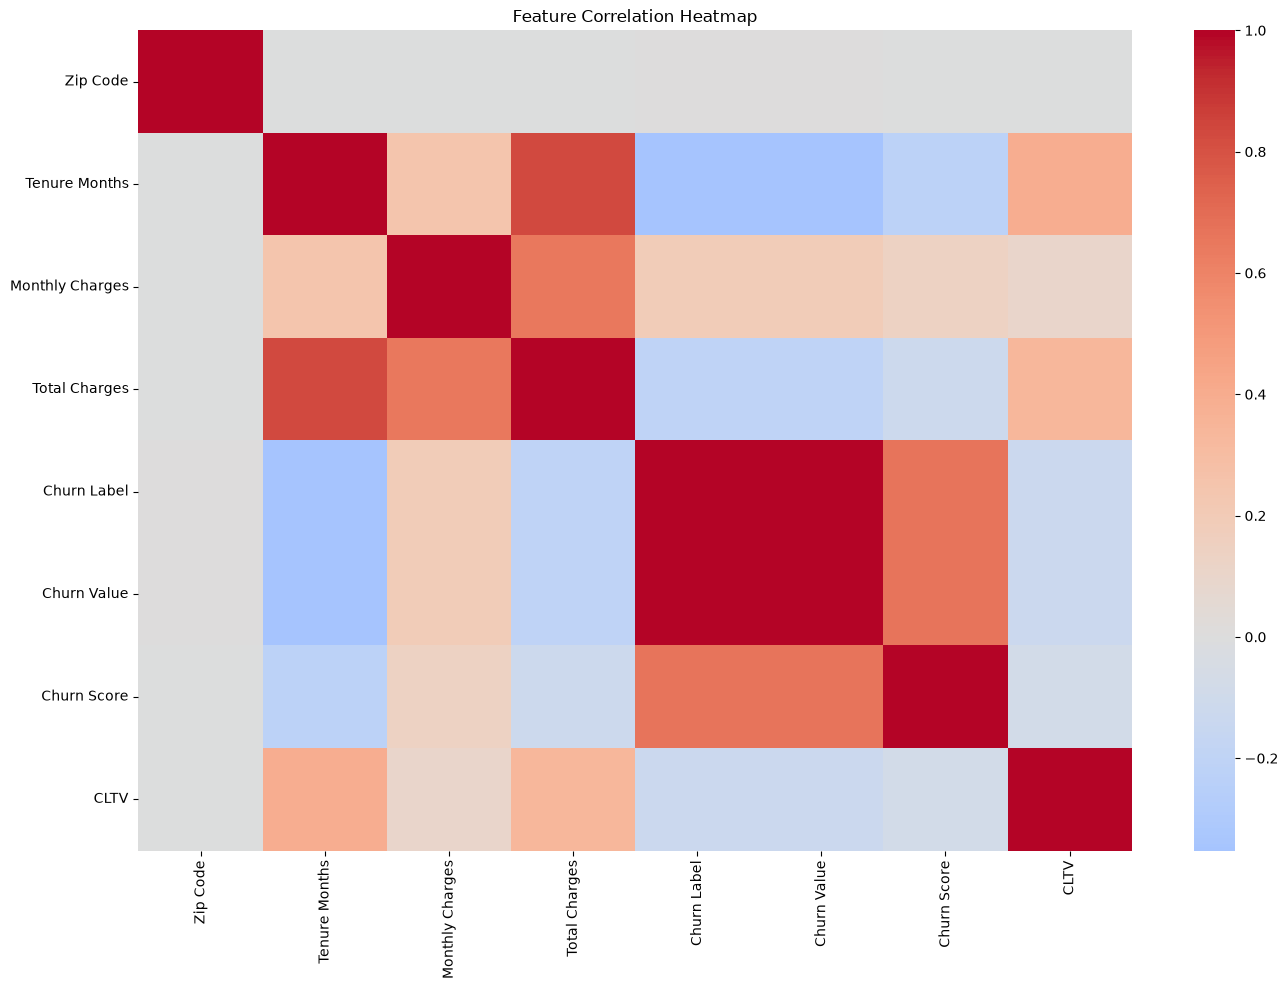

In [22]:
# Correlation Heatmap (excluding geographic and leakage columns)
exclude_cols = ['Count','Country','State','City','ZipCode','LatLong','Latitude','Longitude','ChurnValue','ChurnScore']
heatmap_data = df.drop(columns=[c for c in exclude_cols if c in df.columns])

# Convert ChurnLabel to numeric for correlation
heatmap_data['Churn Label'] = heatmap_data['Churn Label'].map({'Yes': 1, 'No': 0})

plt.figure(figsize=(14, 10))
sns.heatmap(heatmap_data.corr(numeric_only=True), annot=False, cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

Tenure Months and Total Charges are highly correlated, which makes sense because longer customers accumulate more charges. Monthly Charges shows a moderate positive correlation with churn, while Tenure Months shows a negative one, confirming that newer customers with higher bills are at the greatest risk.